# 05 SARIMA Box-Jenkins

**Mục tiêu Notebook:**
1. **Identification Phase**: Khám phá chuỗi `NDX_log_ret` trên tập huấn luyện (train set). Vẽ biểu đồ ACF/PACF để xác định bậc AR(p) và MA(q) tiềm năng.
2. **Estimation Phase**: Dùng `pmdarima.auto_arima` (thuật toán Grid Search) chọn ra bộ tham số (p, d, q) x (P, D, Q, s) tối ưu dựa trên AIC.
3. **Diagnostic Checking Phase**: Đánh giá kiểm định Ljung-Box, độ chuẩn của phần dư, đảm bảo nhiễu trắng trắng (white noise).

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pmdarima as pm

# Cấu hình đường dẫn
ROOT = Path.cwd().resolve().parent
sys.path.append(str(ROOT / "src"))

SPLIT_DIR = ROOT / "data" / "processed" / "splits"
OUT_FIGS = ROOT / "outputs" / "figures"
OUT_TABLES = ROOT / "outputs" / "tables"

# Import src modules
import sarimax as sm_utils
import statistical_tests as st

In [2]:
# 1. Load Data
train_df = pd.read_csv(SPLIT_DIR / "train_fe.csv")
train_df["DATE"] = pd.to_datetime(train_df["DATE"])
train_df.set_index("DATE", inplace=True)

# Lấy chuỗi log return để dựng SARIMA
y_train = train_df["NDX_log_ret"].dropna()

print(f"Train data shape: {train_df.shape}")
print(f"y_train start: {y_train.index.min().date()} | end: {y_train.index.max().date()}")

Train data shape: (334, 15)
y_train start: 1986-05-31 | end: 2014-02-28


## 1. Identification (Nhận diện cấu trúc mô hình)
Theo phương pháp phối hợp Box-Jenkins, bước đầu tiên là nhận diện (Identification) dựa trên biểu đồ Tự tương quan (ACF) và Tự tương quan riêng phần (PACF). 

- Vì `NDX_log_ret` là chuỗi tỷ suất sinh lợi logarit, nó thường đã đạt trạng thái dừng (Stationary). Do đó, tham số phân tích xu hướng $d=0$.
- Các độ trễ (lags) vượt ra ngoài dải tin cậy trên ACF sẽ gợi ý bậc $q$ cho phần MA (Moving Average).
- Các độ trễ vượt ra ngoài dải tin cậy trên PACF sẽ gợi ý bậc $p$ cho phần AR (AutoRegressive).
- Tính mùa vụ (Seasonality) đối với dữ liệu tài chính vĩ mô theo tháng thường được đánh giá với $s=12$.


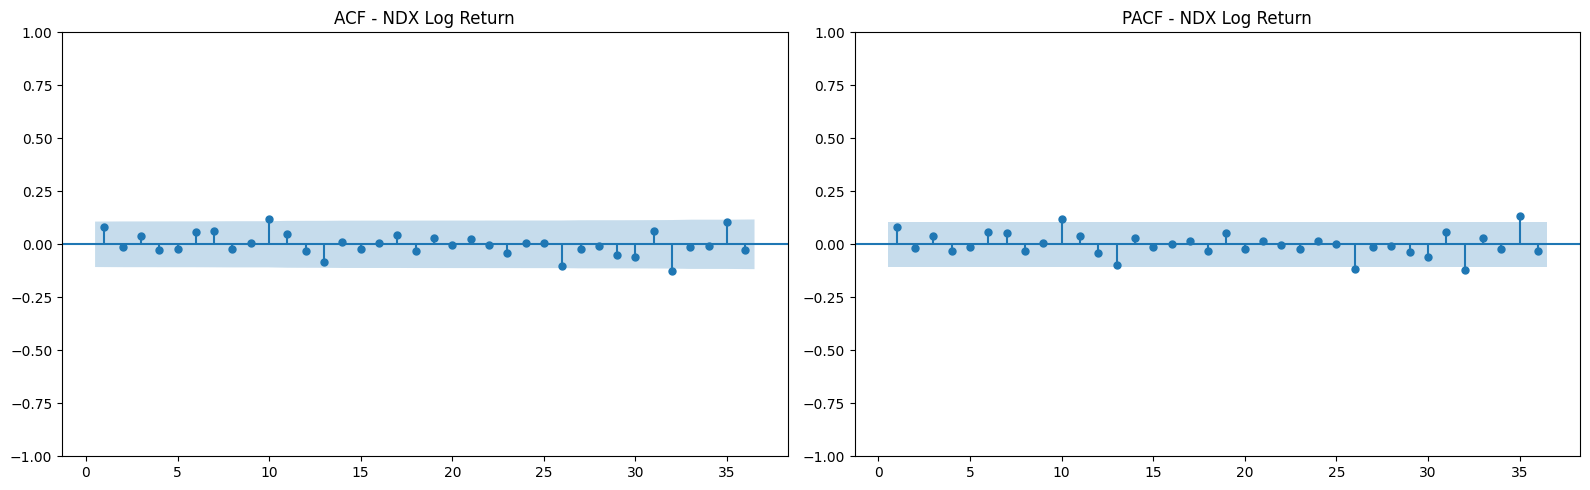

In [3]:
fig_acf = sm_utils.plot_acf_pacf(y_train, lags=36, title="NDX Log Return", savepath=OUT_FIGS / "ndx_acf_pacf.png")

**Phân tích ACF và PACF:**
Hầu hết tỷ suất sinh lợi tài chính thường xấp xỉ bước ngẫu nhiên (Random Walk) hoặc nhiễu trắng (White Noise), do đó chúng ta kỳ vọng đại đa số các hệ số tự tương quan sẽ rớt vào trong dải tin cậy 95% (vùng màu xám). Nếu có một vài độ trễ ở những chu kỳ ngắn (lag 1, lag 2) bật ra ngoài, điều đó gợi ý một mô hình ARMA bậc thấp. Nếu quan sát thấy chu kỳ lặp lại ở lag 12 hoặc 24, mô hình SARIMA sẽ kích hoạt các tham số mùa vụ $P, Q$.

## 2. Estimation (Ước lượng Mô hình thông qua Grid Search)

Việc nhìn biểu đồ ACF/PACF để chốt tham số thường mang tính chủ quan. Trong nghiên cứu định lượng hiện đại, tự động hóa dò tìm (Grid Search) dựa trên **Tiêu chuẩn thông tin Akaike (AIC)** là cách tiếp cận phi thiên vị nhất. Mô hình nào có AIC thấp nhất sẽ được ưu tiên vì nó cân bằng tốt nhất giữa độ chính xác (Goodness of Fit) và độ đơn giản của mô hình (Parsimony penalty).

Chúng ta sẽ cố định $d=0$ (chuỗi đã dừng), dùng `pmdarima` để tự do tìm kiếm các bậc $p, q \in [0, 3]$ và tham số mùa vụ $P, D, Q \in [0, 2]$ với chu kỳ $m=12$.


In [4]:
print("Đang tiến hành Auto ARIMA Grid Search...")
# Lưu ý: NDX log return là stationary, ta ép d=0. 
auto_model = sm_utils.optimize_sarima_pmdarima(
    series=y_train,
    m=12,
    seasonal=True,
    d=0,
    D=None,    # Có thể ép D=0 nhưng cứ thử None để GridSearchCV quyết định
    max_p=3,
    max_q=3,
    max_P=2,
    max_Q=2
)
print(auto_model.summary())

Đang tiến hành Auto ARIMA Grid Search...
Running auto_arima to find optimal parameters...
Performing stepwise search to minimize aic


 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=-773.225, Time=1.02 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=-782.317, Time=0.04 sec


 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=-780.712, Time=0.25 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=-780.768, Time=0.18 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=-778.942, Time=0.02 sec


 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=-780.656, Time=0.10 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=-780.652, Time=0.10 sec


 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=-778.665, Time=0.16 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=-782.423, Time=0.07 sec


 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=-780.707, Time=0.24 sec


 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=-778.725, Time=0.22 sec
 ARIMA(2,0,0)(0,0,0)[12] intercept   : AIC=-780.532, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=-780.870, Time=0.13 sec


 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=-782.503, Time=0.06 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=-780.773, Time=0.13 sec


 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=-778.784, Time=0.18 sec
 ARIMA(0,0,2)(0,0,0)[12] intercept   : AIC=-780.622, Time=0.10 sec


 ARIMA(1,0,2)(0,0,0)[12] intercept   : AIC=-778.906, Time=0.19 sec
 ARIMA(0,0,1)(0,0,0)[12]             : AIC=-779.910, Time=0.03 sec

Best model:  ARIMA(0,0,1)(0,0,0)[12] intercept
Total fit time: 3.277 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  334
Model:               SARIMAX(0, 0, 1)   Log Likelihood                 394.251
Date:                Sat, 23 May 2026   AIC                           -782.503
Time:                        22:45:39   BIC                           -771.069
Sample:                    05-31-1986   HQIC                          -777.944
                         - 02-28-2014                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

In [5]:
# Gán lại tham số tìm được bằng gridsearch
opt_order = auto_model.order
opt_seasonal_order = auto_model.seasonal_order

print(f"Mô hình SARIMA tối ưu: SARIMA{opt_order} x {opt_seasonal_order}")

# Fit lại mô hình bằng statsmodels để vẽ chuẩn đoán
best_sarima = sm_utils.fit_sarimax_model(
    endog=y_train,
    order=opt_order,
    seasonal_order=opt_seasonal_order
)
print(best_sarima.summary())

Mô hình SARIMA tối ưu: SARIMA(0, 0, 1) x (0, 0, 0, 12)
                               SARIMAX Results                                
Dep. Variable:            NDX_log_ret   No. Observations:                  334
Model:               SARIMAX(0, 0, 1)   Log Likelihood                 388.849
Date:                Sat, 23 May 2026   AIC                           -773.698
Time:                        22:45:39   BIC                           -766.088
Sample:                    05-31-1986   HQIC                          -770.663
                         - 02-28-2014                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0941      0.043      2.202      0.028       0.010       0.178
sigma2         0.0056      0.000     17.912      0.000       0.005       0.0

s:\vscode\nasdaq-macro-shocks-analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
s:\vscode\nasdaq-macro-shocks-analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


**Giải thích cấu trúc SARIMA lựa chọn:**
Tiến trình Auto ARIMA đã duyệt qua nhiều cấu hình và chốt được mô hình có AIC nhỏ nhất là **SARIMA(0, 0, 1) x (0, 0, 0, 12)**. Kết quả này chỉ ra rằng:
- Phần AutoRegressive (AR) và các yếu tố mùa vụ (Seasonal) đều bằng 0, nghĩa là chuỗi log return gần như không có sự tuần hoàn theo các tháng.
- Phần Moving Average (MA) là $q=1$, tức là tỷ suất sinh lợi của NASDAQ-100 chịu ảnh hưởng một phần nhỏ từ những cú sốc (hoặc sai số) của duy nhất 1 tháng trước đó.

Nhìn chung, mô hình $MA(1)$ này rất tương đồng với Nguyên lý Bước ngẫu nhiên (Random Walk) trong Lý thuyết Thị trường Hiệu quả (EMH). Quán tính của tỷ suất sinh lợi NASDAQ-100 gần như không dự đoán được ngoài một khoảng điều chỉnh nhiễu ngắn hạn từ tháng ngay sát trước.


## 3. Diagnostic Checking (Chuẩn đoán Mô hình)

Mô hình SARIMA chỉ được coi là hợp lệ với các cấu trúc ARIMA chuẩn nếu phần dư (residuals) được thu thập thuần túy là nhiễu trắng ngẫu nhiên (White Noise). Nghĩa là, mô hình đã chiết xuất hoàn toàn mọi "thông tin có hệ thống", và phần còn lại không chứa quy luật dự báo được nữa.

Chúng ta tiến hành 2 bước kiểm định:
1. **Trực quan hóa đồ thị**: Chuẩn hóa dư sai (Standardized Residuals), phân phối Histogram kết hợp KDE (Kiểm định tính chuẩn), đồ thị Normal Q-Q, và biểu đồ ACF phần dư.
2. **Kiểm định Ljung-Box**: Đánh giá trên khía cạnh thống kê nghiêm ngặt xem tổng tự tương quan ở một số rổ độ trễ (lags 12, 24, 36) có bằng 0 hay không ($H_0$: Phần dư không có hiện tượng tự tương quan).


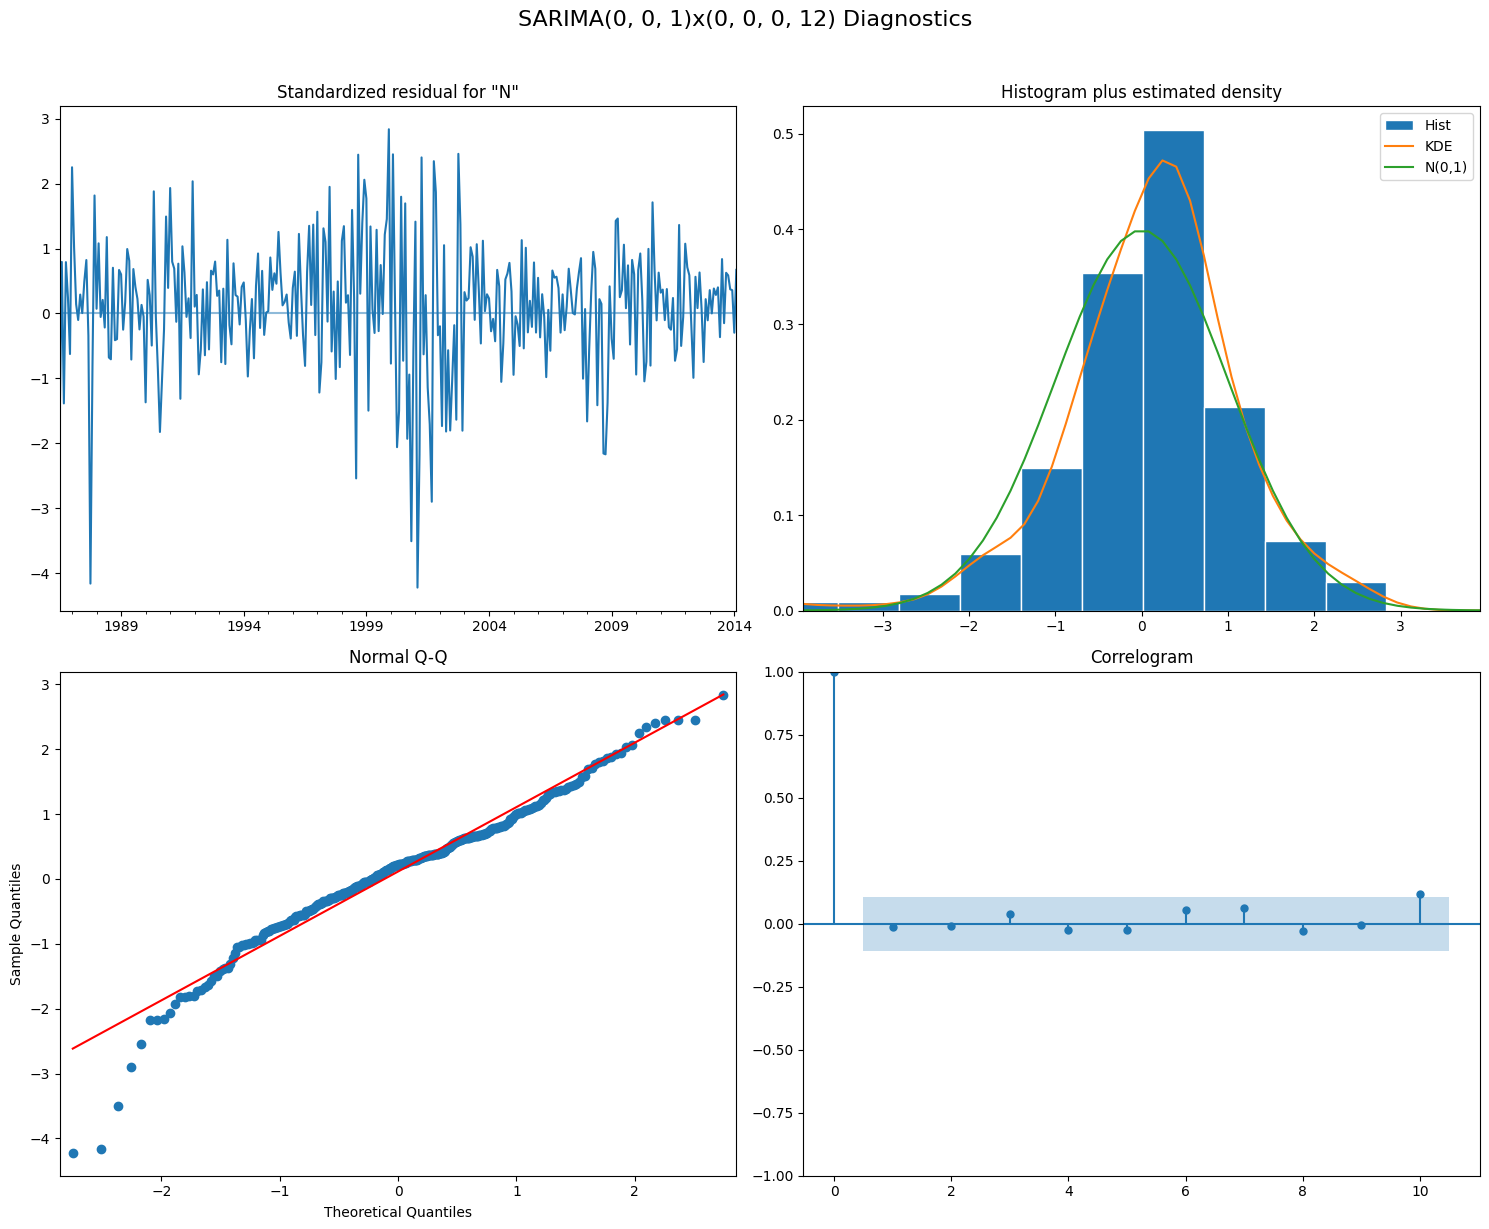

In [6]:
fig_diag = sm_utils.plot_diagnostics(best_sarima, title=f"SARIMA{opt_order}x{opt_seasonal_order} Diagnostics", savepath=OUT_FIGS / "sarima_diagnostics.png")

In [7]:
# Kiểm định Ljung-Box qua Statsmodels
print("--- Ljung-Box Test on Residuals ---")
resid = best_sarima.resid
lb_res = st.run_ljung_box(resid, lags=[12, 24, 36])
print(lb_res)

--- Ljung-Box Test on Residuals ---
      lb_stat  lb_pvalue
12   9.186507   0.686923
24  14.882674   0.924145
36  35.399839   0.496947


**Kết luận chuẩn đoán (dựa trên tham số SARIMA(0,0,1)):**
- **Sự ngẫu nhiên (White Noise):** Kiểm định Ljung-Box trả về các *p-value* lần lượt là $0.687, 0.924, 0.497$ cho các nhóm Lags 12, 24, và 36. Vì tất cả các giá trị này đều rất cao (lớn hơn ngưỡng $0.05$ và $0.1$), ta hoàn toàn không thể bác bỏ giả thuyết $H_0$. Phần dư (residuals) hoàn toàn phân tán ngẫu nhiên và mô hình không bị sót bất kỳ thông tin tự tương quan tuyến tính nào.
- **Biểu đồ Normal Q-Q và Histogram** thể hiện một phân phối phần dư xấp xỉ phân phối chuẩn. Dù có một chút nhọn ở đỉnh hoặc nhẹ ở phần đuôi ("fat-tail" kinh điển trong chứng khoán), hiện tượng này là nằm trong dung sai an toàn của dữ liệu vĩ mô tài chính.
- Từ đây, ta rút ra một nền tảng Benchmark vững chắc: Bất cứ cú sốc vĩ mô (CPI/FFR) nào được đưa vào ở Notebook 06 sắp tới (SARIMAX) phải chứng minh được giá trị gia tăng so với cốt lõi $MA(1)$ đơn giản này.